In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
import torch

# This shows how many GPUs the notebook can see
print(f"Total GPUs available: {torch.cuda.device_count()}")

# This shows the index of the GPU currently in use
print(f"Current GPU index: {torch.cuda.current_device()}")

# This shows the name of the specific card
print(f"Using GPU: {torch.cuda.get_device_name(torch.cuda.current_device())}")

Total GPUs available: 1
Current GPU index: 0
Using GPU: NVIDIA GeForce RTX 4090


In [2]:
from tqdm import tqdm  # 진행률 바(Progress bar) 표시

import torch  # PyTorch 기본 패키지
import torch.nn as nn  # 신경망 레이어/손실 함수 모듈
import torch.optim as optim  # 최적화(Optimizer) 모듈
from torch.utils.data import Dataset, DataLoader  # 데이터셋/데이터로더

import matplotlib  # 시각화 라이브러리(백엔드 설정 등)
import matplotlib.pylab as plt  # 그래프 출력용 pyplot

from torchvision.utils import make_grid, save_image  # 이미지 그리드 생성/이미지 저장
import torchvision.datasets as datasets  # torchvision 내장 데이터셋(MNIST 등)
import torchvision.transforms as transforms  # 데이터 전처리/증강(Transform)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU 사용 가능하면 CUDA, 아니면 CPU
print(device)

cuda


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),                 # PIL 이미지(0~255)를 텐서(0~1)로 변환
    transforms.Normalize((0.5,), (0.5,)),  # (x-0.5)/0.5로 정규화 → 대략 [-1, 1] 범위로 스케일
])

train_dataset = datasets.MNIST(
    root="./data_gen",     # 데이터 저장 폴더
    train=True,            # 학습용(train) 데이터 사용
    transform=transform,   # 위에서 정의한 전처리 적용
    download=True          # 데이터 없으면 자동 다운로드
)

train_loader = DataLoader(
    train_dataset,
    batch_size=512, # 미니배치 크기
    shuffle=True,          # 매 epoch마다 데이터 섞기
    num_workers=0          # 데이터 로딩에 사용할 프로세스 수(Colab/Windows에선 0~2 권장)
)

In [4]:
class Generator(nn.Module):
    def __init__(self, nz):
        super(Generator, self).__init__()
        self.nz = nz  # 잠재벡터(노이즈) 차원

        # MLP(전결합) 기반 생성자: z -> 28*28(=784) 픽셀로 변환
        self.main = nn.Sequential(
            nn.Linear(self.nz, 256),   # nz -> 256
            nn.LeakyReLU(0.2),         # 비선형 활성화(기울기 소실 완화)

            nn.Linear(256, 512),       # 256 -> 512
            nn.LeakyReLU(0.2),

            nn.Linear(512, 1024),      # 512 -> 1024
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 784),      # 1024 -> 784(28*28)
            nn.Tanh(),                 # 출력 범위를 [-1, 1]로 맞춤(정규화와 대응)
        )

    def forward(self, x):
        # (batch, nz) -> (batch, 784) -> (batch, 1, 28, 28)
        return self.main(x).view(-1, 1, 28, 28)  # MNIST는 채널 1(흑백)


In [5]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.n_input = 784  # 입력 이미지(28*28)를 펼친(flatten) 벡터 길이

        # MLP(전결합) 기반 판별자: 이미지 -> 진짜일 확률(0~1)
        self.main = nn.Sequential(
            nn.Linear(self.n_input, 1024),  # 784 -> 1024
            nn.LeakyReLU(0.2),              # 비선형 활성화
            nn.Dropout(0.3),                # 과적합 방지(랜덤으로 일부 뉴런 끄기)

            nn.Linear(1024, 512),           # 1024 -> 512
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),            # 512 -> 256
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 1),              # 256 -> 1 (스칼라 점수)
            nn.Sigmoid(),                   # 0~1 범위 확률로 변환(진짜일 확률)
        )

    def forward(self, x):
        x = x.view(-1, 784)  # (batch, 1, 28, 28) -> (batch, 784)로 펼치기
        return self.main(x)  # (batch, 1): 진짜일 확률 출력


In [6]:
nz=128
generator = Generator(nz).to(device)
discriminator = Discriminator().to(device)
print(generator)
print(discriminator)

Generator(
  (main): Sequential(
    (0): Linear(in_features=128, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=512, out_features=1024, bias=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=1024, out_features=784, bias=True)
    (7): Tanh()
  )
)
Discriminator(
  (main): Sequential(
    (0): Linear(in_features=784, out_features=1024, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=1024, out_features=512, bias=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=512, out_features=256, bias=True)
    (7): LeakyReLU(negative_slope=0.2)
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=256, out_features=1, bias=True)
    (10): Sigmoid()
  )
)


In [7]:
optim_g = optim.Adam(generator.parameters(), lr=0.0002)      # 생성자(G) 업데이트용 Adam 옵티마이저(학습률 2e-4)
optim_d = optim.Adam(discriminator.parameters(), lr=0.0002)  # 판별자(D) 업데이트용 Adam 옵티마이저(학습률 2e-4)

criterion = nn.BCELoss()  # 이진 분류용 손실함수(Binary Cross Entropy): 진짜(1) vs 가짜(0)

losses_g = []  # 생성자 손실 기록용 리스트(그래프/로그에 사용)
losses_d = []  # 판별자 손실 기록용 리스트(그래프/로그에 사용)
images = []    # 생성된 샘플 이미지 저장용 리스트(학습 과정 시각화용)


In [8]:
def train_discriminator(optimizer, data_real, data_fake):
    b_size = data_real.size(0)  # 배치 크기(batch size) 계산

    real_label = torch.ones(b_size, 1).to(device)   # 진짜 라벨=1 (batch, 1)
    fake_label = torch.zeros(b_size, 1).to(device)  # 가짜 라벨=0 (batch, 1)

    optimizer.zero_grad()  # 이전 step의 gradient(기울기) 초기화

    # 1) 진짜 이미지에 대한 판별 결과 및 손실
    output_real = discriminator(data_real)          # D(x_real)
    loss_real = criterion(output_real, real_label)  # 진짜를 1로 맞히도록 학습

    # 2) 가짜 이미지에 대한 판별 결과 및 손실
    output_fake = discriminator(data_fake)          # D(x_fake) original
    loss_fake = criterion(output_fake, fake_label)  # 가짜를 0으로 맞히도록 학습

    # 3) 역전파(backprop): 두 손실에 대해 gradient 계산
    loss_real.backward()  # 진짜 데이터 손실에 대한 기울기 계산
    loss_fake.backward()  # 가짜 데이터 손실에 대한 기울기 계산

    optimizer.step()  # 판별자 파라미터 업데이트

    return loss_real + loss_fake  # 판별자 총 손실 반환(진짜 손실 + 가짜 손실)


In [9]:
def train_generator(optimizer, data_fake):
    b_size = data_fake.size(0)  # 배치 크기 계산

    real_label = torch.ones(b_size, 1).to(device)  # 생성자는 "가짜를 진짜(1)로 속이기"가 목표

    optimizer.zero_grad()  # 이전 step의 gradient 초기화

    output = discriminator(data_fake)      # D(G(z)) : 가짜 이미지가 진짜일 확률
    loss = criterion(output, real_label)   # 가짜를 1로 분류하게 만들도록 손실 계산

    loss.backward()  # 생성자 파라미터에 대한 gradient 계산(역전파)
    optimizer.step()  # 생성자 파라미터 업데이트

    return loss  # 생성자 손실 반환


In [10]:
import os
path = './data_gen/img'
# 디렉토리가 없으면 생성 (상위 디렉토리까지 포함)
if not os.path.exists(path):
    os.makedirs(path, exist_ok=True)
    print(f"디렉토리 생성 완료: {path}")
else:
    print("디렉토리가 이미 존재합니다.")

epochs = 400  # 전체 학습 epoch 수
k=1 # 판별자를 업데이트 하는 수
generator.train()       # 생성자 학습 모드
discriminator.train()   # 판별자 학습 모드

num_batches = len(train_loader)  # 배치 개수(정확)

for epoch in range(epochs):
    loss_g = 0.0  # epoch 생성자 손실 누적(스칼라)
    loss_d = 0.0  # epoch 판별자 손실 누적(스칼라)

    # tqdm 진행률 바: total은 len(train_loader)가 가장 정확
    for idx, data in tqdm(enumerate(train_loader), total=num_batches):
        image, _ = data
        image = image.to(device)  # 진짜 이미지
        b_size = image.size(0)    # 현재 배치 크기

        # (1) 판별자 D를 k번 업데이트
        for step in range(k):
            # D 학습 시 G는 업데이트하지 않도록 detach()
            data_fake = generator(torch.randn(b_size, nz).to(device)).detach()
            data_real = image

            d_loss = train_discriminator(optim_d, data_real, data_fake)  # 텐서 loss
            loss_d += d_loss.item()  # 누적은 .item()으로(파이썬 float)

        # (2) 생성자 G를 1번 업데이트(detach X)
        data_fake = generator(torch.randn(b_size, nz).to(device))
        g_loss = train_generator(optim_g, data_fake)
        loss_g += g_loss.item()  # 누적은 .item()

    # (3) epoch 종료 후 샘플 생성/저장
    generated_img = generator(torch.randn(b_size, nz).to(device)).cpu().detach()
    generated_img = make_grid(generated_img)
    save_image(generated_img, f"./data_gen/img/gen_img{epoch}.png")
    images.append(generated_img)

    # (4) epoch 평균 손실(0으로 나누기 방지: num_batches 사용)
    epoch_loss_g = loss_g / num_batches
    epoch_loss_d = loss_d / num_batches

    losses_g.append(epoch_loss_g)
    losses_d.append(epoch_loss_d)

    print(f"Epoch {epoch} of {epochs}")
    print(f"Generator loss: {epoch_loss_g:.8f}, Discriminator loss: {epoch_loss_d:.8f}")

    
    with torch.no_grad():
        Dx  = discriminator(data_real).mean().item()
        DGz = discriminator(data_fake).mean().item()
    print(f"[epoch {epoch}] Dx={Dx:.3f}, DGz={DGz:.3f}")


디렉토리가 이미 존재합니다.


100%|████████████████████████████████████████████████████████████████████████████████| 118/118 [00:12<00:00,  9.83it/s]


Epoch 0 of 400
Generator loss: 1.13381632, Discriminator loss: 1.00777745
[epoch 0] Dx=0.924, DGz=0.202


100%|████████████████████████████████████████████████████████████████████████████████| 118/118 [00:12<00:00,  9.60it/s]


Epoch 1 of 400
Generator loss: 1.16534489, Discriminator loss: 1.13782702
[epoch 1] Dx=0.693, DGz=0.665


...

Epoch 397 of 400
Generator loss: 1.01460457, Discriminator loss: 1.20777781
[epoch 397] Dx=0.614, DGz=0.381


100%|████████████████████████████████████████████████████████████████████████████████| 118/118 [00:11<00:00, 10.69it/s]


Epoch 398 of 400
Generator loss: 0.98491234, Discriminator loss: 1.20906496
[epoch 398] Dx=0.575, DGz=0.425


100%|████████████████████████████████████████████████████████████████████████████████| 118/118 [00:11<00:00, 10.38it/s]

Epoch 399 of 400
Generator loss: 1.00833869, Discriminator loss: 1.20323184
[epoch 399] Dx=0.566, DGz=0.400


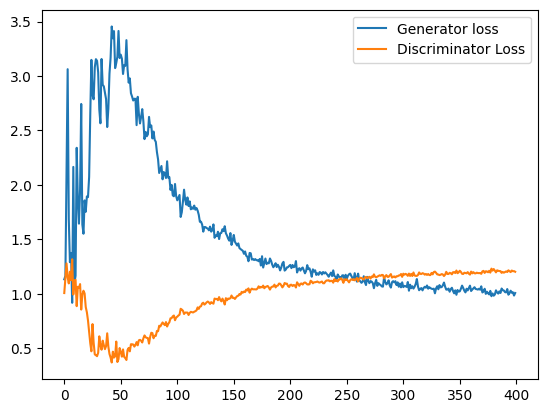

In [11]:
plt.figure()  # 손실 그래프를 그릴 새 Figure 생성

# losses_g가 텐서일 수도 있으니(예: torch.Tensor) 파이썬 숫자(float)로 변환
losses_g = [lg.item() if torch.is_tensor(lg) else lg for lg in losses_g]  # # 생성자 손실 리스트 정리
plt.plot(losses_g, label='Generator loss')  # # 생성자 손실 곡선 그리기

# losses_d도 동일하게 float로 변환
losses_d = [ld.item() if torch.is_tensor(ld) else ld for ld in losses_d]  # # 판별자 손실 리스트 정리
plt.plot(losses_d, label='Discriminator Loss')  # # 판별자 손실 곡선 그리기

plt.legend()  # 범례 표시
plt.show()    # 그래프 출력

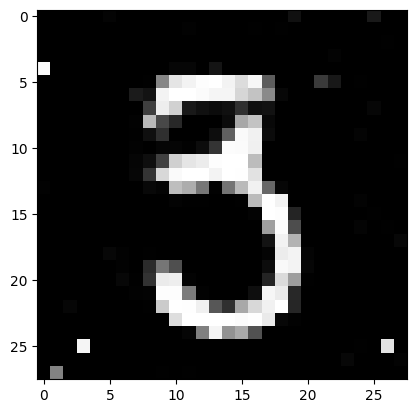

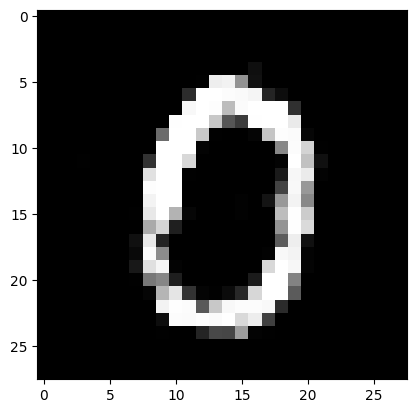

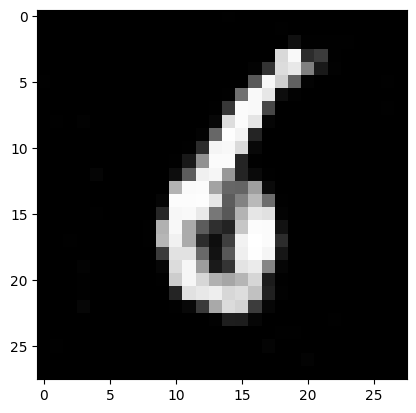

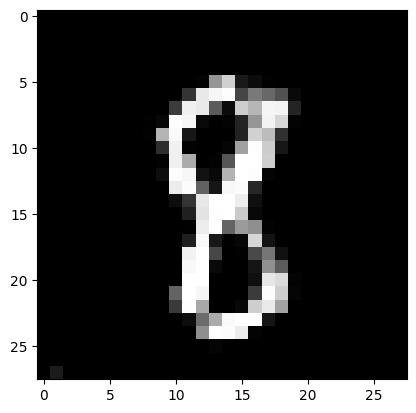

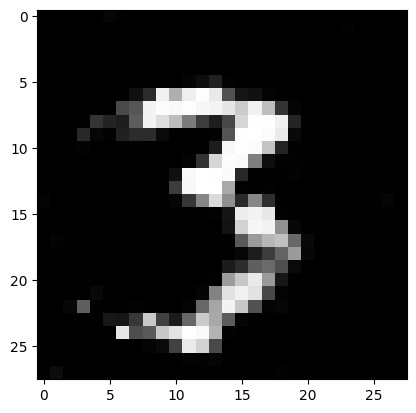

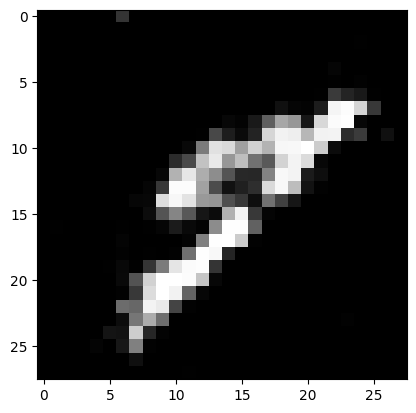

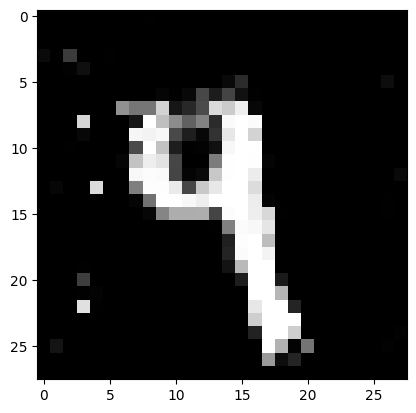

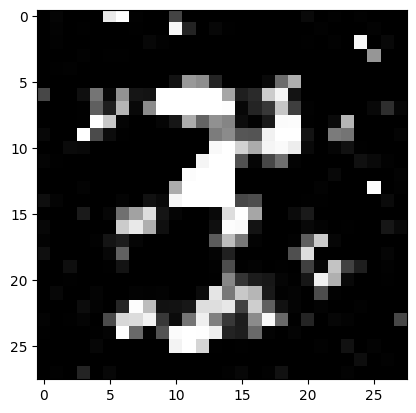

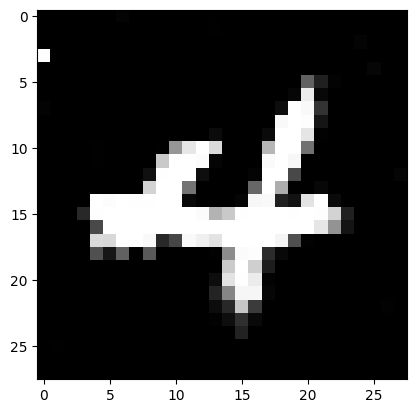

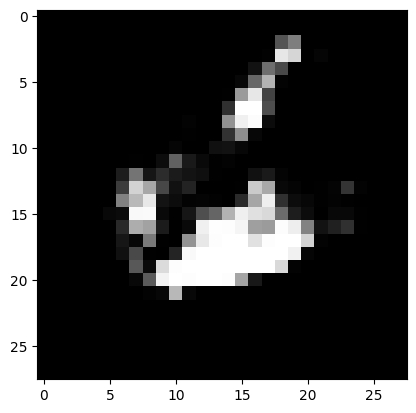

In [12]:
import numpy as np 
# 랜덤 노이즈 z를 넣어서 가짜 이미지 생성 (batch 크기 = b_size)
fake_images = generator(torch.randn(b_size, nz).to(device))

# 생성된 이미지 중 앞의 10장을 화면에 출력
for i in range(10):
    # i번째 이미지를 (28,28) 형태로 reshape해서 numpy로 변환
    fake_images_img = np.reshape(fake_images.data.cpu().numpy()[i], (28, 28))

    # 흑백(gray) 이미지로 시각화
    plt.imshow(fake_images_img, cmap='gray')
    plt.show()  # 이미지 출력

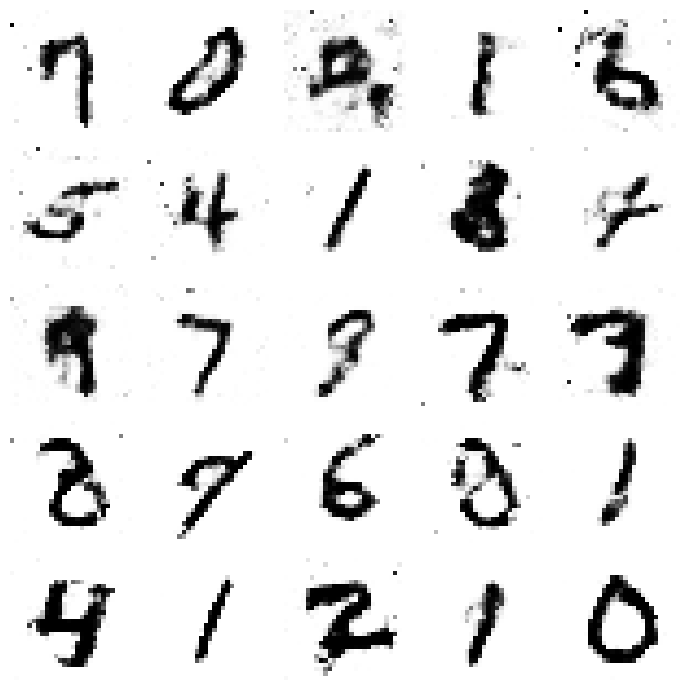

In [13]:
# 25장 생성해서 5x5로 보기 + 색 반전(검은 글씨)
with torch.no_grad():  # # 시각화용이므로 그래프 추적 X
    z = torch.randn(25, nz, device=device)        # # 25개 노이즈 생성
    fake_images = generator(z).cpu()              # # (25, 1, 28, 28) 생성 후 CPU로 이동

fig, axes = plt.subplots(5, 5, figsize=(7, 7))    # # 5x5 서브플롯 생성

for i in range(25):
    # # [-1, 1] 범위를 [0, 1]로 변환 (Tanh 출력 대응)
    img = fake_images[i, 0].numpy()
    img = (img + 1.0) / 2.0

    # # 반전: 흰 글씨 -> 검은 글씨 (배경은 흰색)
    img_inv = 1.0 - img

    ax = axes[i // 5, i % 5]                      # # 5x5 위치 선택
    ax.imshow(img_inv, cmap='gray', vmin=0, vmax=1)  # # 반전된 흑백 이미지 표시
    ax.axis('off')                                # # 축 숨기기

plt.tight_layout()                                # # 간격 자동 조정
plt.show()                                        # # 출력


In [14]:
Dx = discriminator(data_real).mean().item()
print(Dx)
DGz = discriminator(data_fake).mean().item()
print(DGz)

0.5775997638702393
0.38810786604881287
